In [1]:
# Import Libraries
import pandas as pd

In [3]:
# Reading the dataset
df = pd.read_csv('online_retail_cleaned.csv', encoding='latin1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     392692 non-null  int64  
 1   StockCode     392692 non-null  object 
 2   Description   392692 non-null  object 
 3   Quantity      392692 non-null  int64  
 4   InvoiceDate   392692 non-null  object 
 5   UnitPrice     392692 non-null  float64
 6   CustomerID    392692 non-null  int64  
 7   Country       392692 non-null  object 
 8   TotalPrice    392692 non-null  float64
 9   Year          392692 non-null  int64  
 10  Month         392692 non-null  int64  
 11  Day           392692 non-null  int64  
 12  Weekday       392692 non-null  int64  
 13  Hour          392692 non-null  int64  
 14  TotalRevenue  392692 non-null  float64
dtypes: float64(3), int64(8), object(4)
memory usage: 44.9+ MB


In [4]:
from sklearn.preprocessing import StandardScaler
# Define threshold for high vs. low spending customers
df['HighSpender'] = (df['TotalRevenue'] > df['TotalRevenue'].median()).astype(int)

# Define features (X) and target (y)
X = df[['Quantity', 'UnitPrice', 'TotalPrice', 'Month', 'Day', 'Weekday', 'Hour']]
y = df['HighSpender']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7787213995594545


In [8]:
from xgboost import XGBClassifier

# Train the model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6904085868167408


In [9]:
from sklearn.linear_model import LogisticRegression

# Train the model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5661263830708311


In [10]:
from sklearn.cluster import KMeans

# Features for clustering
X_cluster = df[['Quantity', 'UnitPrice', 'TotalPrice', 'TotalRevenue']]

# Standardize features
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means clustering with 3 segments
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Show cluster counts
print(df['Cluster'].value_counts())

Cluster
0    381028
2     11662
1         2
Name: count, dtype: int64


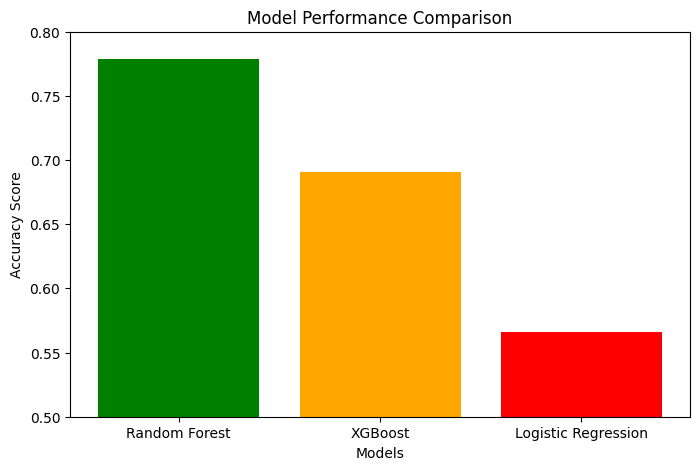

In [11]:
#Visualization of accuracy scores
import matplotlib.pyplot as plt

# Model names and accuracy scores
models = ["Random Forest", "XGBoost", "Logistic Regression"]
accuracies = [0.7787, 0.6904, 0.5661]

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['green', 'orange', 'red'])
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Performance Comparison")
plt.ylim(0.5, 0.8)  # Set y-axis limits
plt.show()

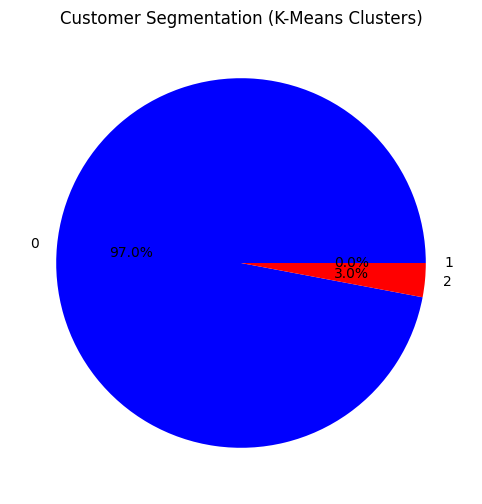

In [12]:
# Cluster distribution
clusters = df['Cluster'].value_counts()

# Pie chart
plt.figure(figsize=(8,6))
plt.pie(clusters, labels=clusters.index, autopct='%1.1f%%', colors=['blue', 'red', 'green'])
plt.title("Customer Segmentation (K-Means Clusters)")
plt.show()

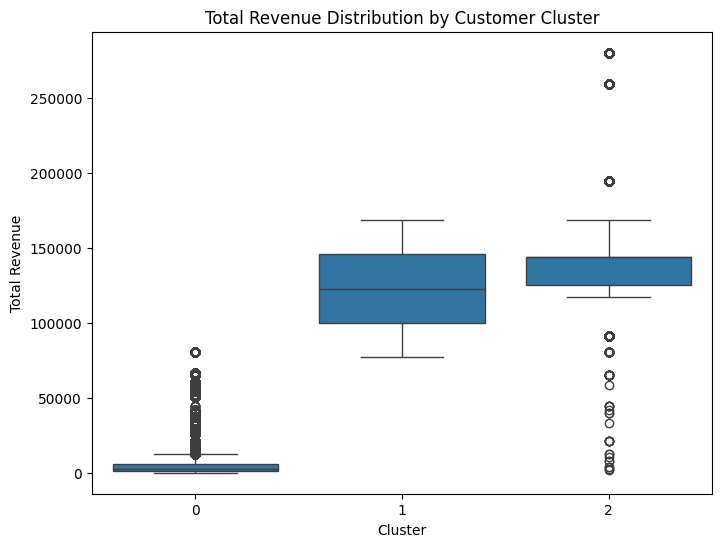

In [13]:
import seaborn as sns

# Boxplot of TotalRevenue across clusters
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Cluster'], y=df['TotalRevenue'])
plt.title("Total Revenue Distribution by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.show()